# Phase 3 (VAE) — Health-Check: window_10_0pct clean train, Dense's labeled val/test

**Goal of this first pass:** confirm the VAE trains without collapsing and produces a
reasonable AUC/F1 against Dense's existing labeled val/test split
(`phase3_dense/03_phase3_splits/{val,test}_indices.csv`) — **not** an architecture
comparison against Dense. That split is reused here purely as a labeled evaluation set;
Dense's own split/files are read-only from this notebook.

Train set: `phase3_vae/window10_clean_train.csv` (4356 benign-only flows, already
scaled/encoded with Dense's *refit* StandardScaler/OneHotEncoder — see
`prepare_window10.py` for why: keeps window_10 on the same feature scale as val/test
without ever touching Dense's frozen pipeline).

Input dimensionality is **18**, not the file's 22 columns — `is_attack`,
`actual_attack_pct`, `window_id`, `ts` are metadata/label, not model input
(including `is_attack` as a feature would leak the label into training).

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, accuracy_score

BASE = Path.cwd()
PROJECT_ROOT = BASE.parent
DENSE_SPLIT_DIR = PROJECT_ROOT / "phase3_dense" / "03_phase3_splits"
FEAT_ALL_PATH = Path.home() / "Desktop" / "NIDS" / "data" / "ids-dataset-features" / "features_all_windows.csv"
TRAIN_PATH = BASE / "window10_clean_train.csv"

MODEL_DIR = BASE / "04_phase3_models"
RESULTS_DIR = BASE / "05_phase3_results"
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print(f"TensorFlow {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")

FEATURE_COLS = [
    "duration_scaled", "orig_bytes_scaled", "resp_bytes_scaled",
    "orig_pkts_scaled", "resp_pkts_scaled",
    "bytes_per_sec_scaled", "pkts_per_sec_scaled", "byte_ratio_scaled",
    "proto_tcp", "proto_udp",
    "service_dns", "service_http", "service_none", "service_ssh",
    "conn_state_REJ", "conn_state_RSTO", "conn_state_S1", "conn_state_SF",
]
INPUT_DIM = len(FEATURE_COLS)
assert INPUT_DIM == 18, INPUT_DIM
print(f"INPUT_DIM = {INPUT_DIM} (18 feature columns - is_attack/actual_attack_pct/window_id/ts excluded)")

BETA = 1.0            # KL weight - change here to try beta-VAE variants
LATENT_CANDIDATES = [6, 8, 10]
AUC_TOLERANCE = 0.01  # a larger latent must beat the smallest by more than this to be worth the extra capacity
DROPOUT_RATE = 0.1
BATCH_SIZE = 64
EPOCHS = 200
PATIENCE = 12
SEED = 0


TensorFlow 2.21.0, GPU: []
INPUT_DIM = 18 (18 feature columns - is_attack/actual_attack_pct/window_id/ts excluded)


## 1. Data loading — VAE train = window_10, val/test = Dense's labeled split (read-only)

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
assert (train_df["is_attack"] == 0).all(), "VAE train split must be 100%% benign"
X_train = train_df[FEATURE_COLS].values.astype("float32")

features_all = pd.read_csv(FEAT_ALL_PATH)
val_idx = pd.read_csv(DENSE_SPLIT_DIR / "val_indices.csv")["row_index"].values
test_idx = pd.read_csv(DENSE_SPLIT_DIR / "test_indices.csv")["row_index"].values
val_df = features_all.iloc[val_idx].reset_index(drop=True)
test_df = features_all.iloc[test_idx].reset_index(drop=True)

val_benign_mask = val_df["is_attack"] == 0
X_val_benign = val_df.loc[val_benign_mask, FEATURE_COLS].values.astype("float32")
X_val_all = val_df[FEATURE_COLS].values.astype("float32")
y_val = val_df["is_attack"].values
X_test = test_df[FEATURE_COLS].values.astype("float32")
y_test = test_df["is_attack"].values

print(f"train (window_10, 100% benign): {len(train_df)}")
print(f"val: {len(val_df)} ({int(val_benign_mask.sum())} benign, {int((~val_benign_mask).sum())} attack)")
print(f"test: {len(test_df)} ({int((test_df['is_attack']==0).sum())} benign, {int((test_df['is_attack']==1).sum())} attack)")


train (window_10, 100% benign): 4356
val: 6576 (4609 benign, 1967 attack)
test: 6581 (4678 benign, 1903 attack)


## 2. VAE model

`Dense(16, relu) -> Dropout(0.1) -> Dense(8, relu) -> [z_mean, z_log_var]` encoder,
reparameterization trick, symmetric decoder `Dense(8, relu) -> Dense(16, relu) -> Dense(18, linear)`.

Loss = `MSE(reconstruction) + beta * KL`. No BatchNorm (4356 rows / small batches make
BatchNorm's running statistics noisy for a net this shallow) — regularization instead
comes from the KL term itself plus a single light Dropout layer and early stopping,
matching Dense's `EarlyStopping(patience=12, monitor=val_loss)` convention.

In [3]:
# ClipLogVar / VAE2 now live in phase3_vae/model_layers.py (shared module, not
# notebook-only) so any future script can `import model_layers` and get a
# class already registered with @tf.keras.utils.register_keras_serializable -
# required before load_model() can deserialize a saved encoder/decoder.
import sys
if str(BASE) not in sys.path:
    sys.path.insert(0, str(BASE))
from model_layers import ClipLogVar, VAE2


In [4]:
class VAE(tf.keras.Model):
    def __init__(self, input_dim, latent_dim, beta=1.0, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.beta = beta

        enc_in = tf.keras.Input(shape=(input_dim,))
        x = tf.keras.layers.Dense(16, activation="relu")(enc_in)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        x = tf.keras.layers.Dense(8, activation="relu")(x)
        z_mean = tf.keras.layers.Dense(latent_dim, name="z_mean")(x)
        z_log_var_raw = tf.keras.layers.Dense(latent_dim, name="z_log_var")(x)
        # Clip log-variance: unconstrained it can shoot to large values early in
        # training (before KL pulls it back), exp() of which overflows to inf/NaN -
        # standard VAE stabilization, not a hack.
        z_log_var = ClipLogVar()(z_log_var_raw)
        self.encoder = tf.keras.Model(enc_in, [z_mean, z_log_var], name="encoder")

        dec_in = tf.keras.Input(shape=(latent_dim,))
        y = tf.keras.layers.Dense(8, activation="relu")(dec_in)
        y = tf.keras.layers.Dense(16, activation="relu")(y)
        dec_out = tf.keras.layers.Dense(input_dim, activation="linear")(y)
        self.decoder = tf.keras.Model(dec_in, dec_out, name="decoder")

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs, training=False):
        z_mean, z_log_var = self.encoder(inputs, training=training)
        eps = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * eps
        recon = self.decoder(z, training=training)
        return recon, z_mean, z_log_var

    def _compute_losses(self, x, y):
        recon, z_mean, z_log_var = self(x, training=True)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(y - recon), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, y)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, y)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


def reconstruction_error(model, X):
    recon, _, _ = model(X, training=False)
    return np.mean(np.square(X - recon.numpy()), axis=1)


def build_and_train(latent_dim, seed):
    tf.keras.utils.set_random_seed(seed)
    model = VAE(INPUT_DIM, latent_dim, beta=BETA, dropout_rate=DROPOUT_RATE)
    model.compile(optimizer=tf.keras.optimizers.Adam(clipnorm=1.0))
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    t0 = time.time()
    history = model.fit(
        X_train, X_train, validation_data=(X_val_benign, X_val_benign),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, callbacks=[early_stop], verbose=0,
    )
    train_time = time.time() - t0
    return model, history, train_time


## 3. Latent-dimension sweep (6 / 8 / 10) — val AUC + val reconstruction loss for each

In [5]:
sweep_rows = []
sweep_models = {}
for latent_dim in LATENT_CANDIDATES:
    model, history, train_time = build_and_train(latent_dim, seed=SEED)
    val_errors = reconstruction_error(model, X_val_all)
    val_auc = roc_auc_score(y_val, val_errors)
    val_recon_loss = history.history["val_recon_loss"][-1]
    val_kl_loss = history.history["val_kl_loss"][-1]
    epochs_run = len(history.history["loss"])
    sweep_rows.append({
        "latent_dim": latent_dim, "val_auc": val_auc, "val_recon_loss": val_recon_loss,
        "val_kl_loss": val_kl_loss, "epochs_run": epochs_run, "train_time_sec": round(train_time, 1),
    })
    sweep_models[latent_dim] = (model, history)
    print(f"latent={latent_dim}: val_AUC={val_auc:.4f} val_recon_loss={val_recon_loss:.4f} "
          f"val_kl_loss={val_kl_loss:.4f} epochs={epochs_run} time={train_time:.1f}s")

sweep_df = pd.DataFrame(sweep_rows).set_index("latent_dim")
sweep_df


latent=6: val_AUC=0.7215 val_recon_loss=3.0305 val_kl_loss=1.3453 epochs=59 time=6.7s


latent=8: val_AUC=0.7203 val_recon_loss=1.4004 val_kl_loss=1.1105 epochs=196 time=19.7s


latent=10: val_AUC=0.8014 val_recon_loss=5.9707 val_kl_loss=0.3737 epochs=171 time=17.6s


,val_auc,val_recon_loss,val_kl_loss,epochs_run,train_time_sec
latent_dim,,,,,
6,0.721507,3.030543,1.345314,59,6.7
8,0.720268,1.400392,1.110505,196,19.7
10,0.801418,5.970677,0.373667,171,17.6


## 4. Latent selection — reasoned, not "pick max AUC"

Rule: start from the **smallest** latent dimension (most compression, simplest model,
strongest regularization for a 4356-row training set). Only move to a larger latent if
it beats the smallest by more than `AUC_TOLERANCE` (0.01 AUC) — otherwise the extra
capacity isn't earning its keep and the smaller/simpler model is preferred.

In [6]:
best_auc = sweep_df["val_auc"].max()
smallest_latent = min(LATENT_CANDIDATES)
smallest_auc = sweep_df.loc[smallest_latent, "val_auc"]

chosen_latent = smallest_latent
reasoning = [f"smallest candidate latent={smallest_latent}: val_AUC={smallest_auc:.4f} (baseline)"]
for latent_dim in sorted(LATENT_CANDIDATES):
    if latent_dim == smallest_latent:
        continue
    auc = sweep_df.loc[latent_dim, "val_auc"]
    gain = auc - sweep_df.loc[chosen_latent, "val_auc"]
    if gain > AUC_TOLERANCE:
        reasoning.append(f"latent={latent_dim}: val_AUC={auc:.4f}, +{gain:.4f} over current pick "
                          f"({chosen_latent}) > tolerance ({AUC_TOLERANCE}) -> switching to latent={latent_dim}")
        chosen_latent = latent_dim
    else:
        reasoning.append(f"latent={latent_dim}: val_AUC={auc:.4f}, +{gain:.4f} over current pick "
                          f"({chosen_latent}) <= tolerance ({AUC_TOLERANCE}) -> not worth the extra capacity, keeping latent={chosen_latent}")

print("\n".join(reasoning))
print(f"\n=> SELECTED latent_dim = {chosen_latent} (AUC/simplicity tradeoff, not blind argmax)")

vae, vae_history = sweep_models[chosen_latent]


smallest candidate latent=6: val_AUC=0.7215 (baseline)
latent=8: val_AUC=0.7203, +-0.0012 over current pick (6) <= tolerance (0.01) -> not worth the extra capacity, keeping latent=6
latent=10: val_AUC=0.8014, +0.0799 over current pick (6) > tolerance (0.01) -> switching to latent=10

=> SELECTED latent_dim = 10 (AUC/simplicity tradeoff, not blind argmax)


## 5. Loss curves + KL collapse check (selected model)

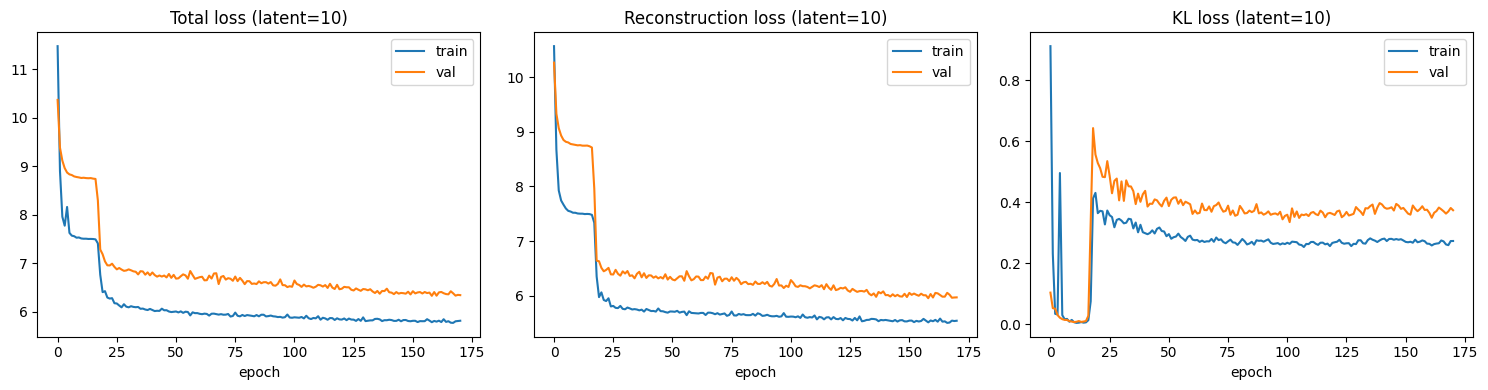

Mean train KL loss over last 34 epochs: 0.271505
z_mean across train set: per-dim std = [0.027  0.0274 0.5356 0.0224 0.0643 0.1105 0.0712 0.069  0.0703 0.0636]
z_log_var across train set: per-dim mean = [-0.0012 -0.0011 -0.4812 -0.0031 -0.0173 -0.0164 -0.0101 -0.0114 -0.009
 -0.014 ]

OK: no collapse signature - KL loss is non-trivial and z_mean varies across inputs (model is actually using the latent space, not ignoring it).


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "recon_loss", "kl_loss"], ["Total loss", "Reconstruction loss", "KL loss"]):
    ax.plot(vae_history.history[key], label="train")
    ax.plot(vae_history.history[f"val_{key}"], label="val")
    ax.set_title(f"{title} (latent={chosen_latent})")
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()

# --- KL collapse diagnostic ---
# Two independent signals checked, either one alone would already be suspicious:
#  1. kl_loss staying near 0 for the whole run (posterior ~= prior, decoder ignoring z)
#  2. z_log_var/z_mean computed over the actual training data collapsing to a constant
#     (same latent code regardless of input - decoder degenerates to reconstructing the mean)
final_epochs = max(1, len(vae_history.history['kl_loss']) // 5)
mean_kl_last = float(np.mean(vae_history.history['kl_loss'][-final_epochs:]))
print(f"Mean train KL loss over last {final_epochs} epochs: {mean_kl_last:.6f}")

z_mean_train, z_log_var_train = vae.encoder(X_train, training=False)
z_mean_train, z_log_var_train = z_mean_train.numpy(), z_log_var_train.numpy()
print(f"z_mean across train set: per-dim std = {z_mean_train.std(axis=0).round(4)}")
print(f"z_log_var across train set: per-dim mean = {z_log_var_train.mean(axis=0).round(4)}")

KL_COLLAPSE_THRESHOLD = 0.01
ZMEAN_STD_COLLAPSE_THRESHOLD = 0.05
kl_collapsed = mean_kl_last < KL_COLLAPSE_THRESHOLD
zmean_collapsed = bool((z_mean_train.std(axis=0) < ZMEAN_STD_COLLAPSE_THRESHOLD).all())

if kl_collapsed or zmean_collapsed:
    print(f"\n*** WARNING: possible KL/posterior collapse detected "
          f"(mean_kl_last={mean_kl_last:.6f} < {KL_COLLAPSE_THRESHOLD} : {kl_collapsed}, "
          f"z_mean per-dim std all < {ZMEAN_STD_COLLAPSE_THRESHOLD} : {zmean_collapsed}) ***")
else:
    print(f"\nOK: no collapse signature - KL loss is non-trivial and z_mean varies across inputs "
          f"(model is actually using the latent space, not ignoring it).")


## 6. Threshold calibration (val) — pctl95 on val-benign error + Youden's J

In [8]:
val_errors_benign = reconstruction_error(vae, X_val_benign)
val_errors_all = reconstruction_error(vae, X_val_all)

thr_pctl = float(np.percentile(val_errors_benign, 95))
fpr, tpr, roc_thresholds = roc_curve(y_val, val_errors_all)
thr_youden = float(roc_thresholds[np.argmax(tpr - fpr)])
print(f"threshold (val benign pctl95) = {thr_pctl:.5f}")
print(f"threshold (val Youden's J)    = {thr_youden:.5f}")


threshold (val benign pctl95) = 0.46198
threshold (val Youden's J)    = 0.08155


## 7. Test evaluation — AUC, F1, ROC curve, reconstruction-error histogram

TEST AUC = 0.9243
pctl95  -> {'precision': 0.882798833819242, 'recall': 0.7955859169732002, 'f1': 0.8369264787175235, 'accuracy': 0.9103479714329129, 'threshold': 0.4619750320911403}
youden  -> {'precision': 0.5157266811279827, 'recall': 0.999474513925381, 'f1': 0.680379180826328, 'accuracy': 0.7284607202552803, 'threshold': 0.0815497413277626}


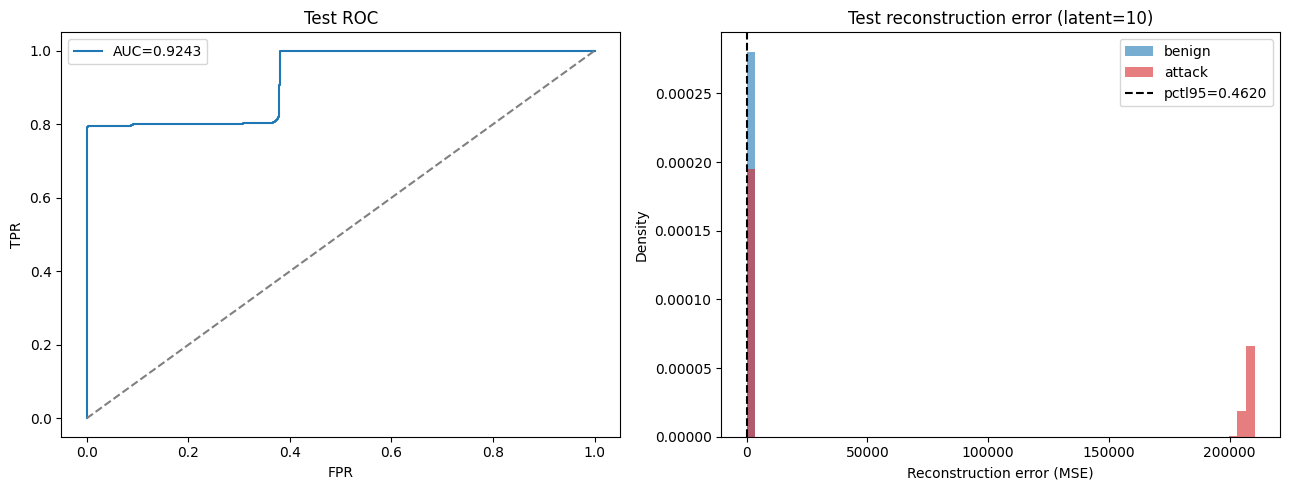

In [9]:
def evaluate_at_threshold(y_true, errors, threshold):
    y_pred = (errors > threshold).astype(int)
    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "threshold": float(threshold),
    }

test_errors = reconstruction_error(vae, X_test)
test_auc = float(roc_auc_score(y_test, test_errors))
metrics_pctl = evaluate_at_threshold(y_test, test_errors, thr_pctl)
metrics_youden = evaluate_at_threshold(y_test, test_errors, thr_youden)

print(f"TEST AUC = {test_auc:.4f}")
print(f"pctl95  -> {metrics_pctl}")
print(f"youden  -> {metrics_youden}")

fpr_t, tpr_t, _ = roc_curve(y_test, test_errors)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr_t, tpr_t, label=f"AUC={test_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("Test ROC"); axes[0].legend()

benign_errors_test = test_errors[y_test == 0]
attack_errors_test = test_errors[y_test == 1]
bins = np.linspace(0, np.percentile(test_errors, 99), 60)
axes[1].hist(benign_errors_test, bins=bins, alpha=0.6, label="benign", color="tab:blue", density=True)
axes[1].hist(attack_errors_test, bins=bins, alpha=0.6, label="attack", color="tab:red", density=True)
axes[1].axvline(thr_pctl, color="black", linestyle="--", label=f"pctl95={thr_pctl:.4f}")
axes[1].set_xlabel("Reconstruction error (MSE)"); axes[1].set_ylabel("Density")
axes[1].set_title(f"Test reconstruction error (latent={chosen_latent})"); axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Save health-check results

In [10]:
result = {
    "chosen_latent_dim": chosen_latent,
    "latent_sweep": sweep_df.reset_index().to_dict(orient="records"),
    "selection_reasoning": reasoning,
    "kl_collapse_check": {
        "mean_kl_last_epochs": mean_kl_last,
        "z_mean_per_dim_std": z_mean_train.std(axis=0).tolist(),
        "z_log_var_per_dim_mean": z_log_var_train.mean(axis=0).tolist(),
        "collapsed": bool(kl_collapsed or zmean_collapsed),
    },
    "threshold_pctl95": metrics_pctl,
    "threshold_youden": metrics_youden,
    "test_auc": test_auc,
    "epochs_run": len(vae_history.history["loss"]),
}
with open(RESULTS_DIR / "healthcheck_summary.json", "w") as f:
    json.dump(result, f, indent=2)

# This is a health-check/sweep model, not the final architecture (see section 9) -
# it's saved to its own latest_run/ subfolder, never straight into 04_phase3_models/,
# so re-running this notebook (e.g. for a future AUC-improvement pass) can never
# silently overwrite or collide with the approved final model files there. Any
# *.keras already sitting in latest_run/ from a previous run is archived in place
# (timestamp suffix) first, so no run's output is ever silently lost either.
LATEST_RUN_DIR = MODEL_DIR / "latest_run"
LATEST_RUN_DIR.mkdir(exist_ok=True)

existing_run_files = list(LATEST_RUN_DIR.glob("*.keras"))
if existing_run_files:
    run_ts = time.strftime("%Y%m%d-%H%M")
    for f in existing_run_files:
        archived_name = f"{f.stem}_run{run_ts}{f.suffix}"
        f.rename(LATEST_RUN_DIR / archived_name)
        print(f"Archived previous latest_run/ file: {f.name} -> {archived_name}")

vae.encoder.save(LATEST_RUN_DIR / f"vae_encoder_latent{chosen_latent}.keras")
vae.decoder.save(LATEST_RUN_DIR / f"vae_decoder_latent{chosen_latent}.keras")
print(f"Saved: {RESULTS_DIR / 'healthcheck_summary.json'}")
print(f"Saved: {LATEST_RUN_DIR / f'vae_encoder_latent{chosen_latent}.keras'}, vae_decoder_latent{chosen_latent}.keras")
print(f"\nModel latest_run/'a kaydedildi. Bunu final olarak onaylamak icin elle "
      f"04_phase3_models/ kokune veya ilgili final_* adiyla tasi.")


Archived previous latest_run/ file: vae_decoder_latent10.keras -> vae_decoder_latent10_run20260718-1337.keras
Archived previous latest_run/ file: vae_encoder_latent10.keras -> vae_encoder_latent10_run20260718-1337.keras
Saved: /Users/mustafa/Desktop/NIDS/IDS-Project/phase3_vae/05_phase3_results/healthcheck_summary.json
Saved: /Users/mustafa/Desktop/NIDS/IDS-Project/phase3_vae/04_phase3_models/latest_run/vae_encoder_latent10.keras, vae_decoder_latent10.keras

Model latest_run/'a kaydedildi. Bunu final olarak onaylamak icin elle 04_phase3_models/ kokune veya ilgili final_* adiyla tasi.


## 9. Addressing partial posterior collapse (latent=10, 9/10 dims inactive)

Two standard fixes, compared against the beta=1.0 baseline above:

1. **Weaker beta** (0.5, 0.25) — de-weight the KL term so reconstruction pressure
   dominates, which should keep more latent dims "worth using" instead of letting them
   collapse to the prior.
2. **KL annealing** — beta ramps from 0 to the target (1.0) on a sigmoid schedule over
   the first `ANNEAL_EPOCHS` epochs (sigmoid chosen over linear: smoother ramp, avoids
   a hard early kink in the loss landscape right as reconstruction is still catching
   up - the original Bowman et al. 2016 KL-annealing paper uses the same shape). Model
   learns to reconstruct first, KL pressure phases in gradually after.

**Active dim** = a latent dimension whose `z_mean` std across the *training set* is
above `ACTIVE_STD_THRESHOLD` (0.15) - i.e. it actually varies with the input, as
opposed to collapsing to a constant (the prior).

In [11]:
ACTIVE_STD_THRESHOLD = 0.15
ANNEAL_EPOCHS = 40

def count_active_dims(model, X):
    z_mean, _ = model.encoder(X, training=False)
    stds = z_mean.numpy().std(axis=0)
    return int((stds > ACTIVE_STD_THRESHOLD).sum()), stds


class BetaScheduler(tf.keras.callbacks.Callback):
    """Sigmoid ramp from 0 to target_beta over anneal_epochs, then holds at target."""
    def __init__(self, target_beta, anneal_epochs):
        super().__init__()
        self.target_beta = target_beta
        self.anneal_epochs = anneal_epochs

    def on_epoch_begin(self, epoch, logs=None):
        if self.anneal_epochs <= 0 or epoch >= self.anneal_epochs:
            new_beta = self.target_beta
        else:
            k = 10.0 / self.anneal_epochs
            new_beta = self.target_beta / (1.0 + np.exp(-k * (epoch - self.anneal_epochs / 2)))
        self.model.beta.assign(new_beta)


# VAE2 is imported from model_layers (see section 2) - same architecture as
# VAE, but beta is a tf.Variable so a callback can anneal it mid-training
# (VAE's beta was a plain float, fixed for the whole run).


def build_and_train_v2(latent_dim, beta_target, seed, anneal_epochs=0):
    tf.keras.utils.set_random_seed(seed)
    beta_init = 0.0 if anneal_epochs > 0 else beta_target
    model = VAE2(INPUT_DIM, latent_dim, beta_init=beta_init, dropout_rate=DROPOUT_RATE)
    model.compile(optimizer=tf.keras.optimizers.Adam(clipnorm=1.0))
    callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)]
    if anneal_epochs > 0:
        callbacks.append(BetaScheduler(beta_target, anneal_epochs))
    t0 = time.time()
    history = model.fit(
        X_train, X_train, validation_data=(X_val_benign, X_val_benign),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True, callbacks=callbacks, verbose=0,
    )
    return model, history, time.time() - t0


### 9.1 Run all variants (latent=10 fixed) and compare

In [12]:
VARIANTS = [
    ("beta=1.0 (baseline)", 1.0, 0),
    ("beta=0.5", 0.5, 0),
    ("beta=0.25", 0.25, 0),
    ("KL-annealing (sigmoid -> 1.0)", 1.0, ANNEAL_EPOCHS),
]

variant_rows = []
variant_models = {}
for name, beta_target, anneal_epochs in VARIANTS:
    model, history, train_time = build_and_train_v2(LATENT_FIXED := chosen_latent, beta_target, seed=SEED, anneal_epochs=anneal_epochs)
    n_active_val, stds_val = count_active_dims(model, X_val_benign)
    n_active_train, stds_train = count_active_dims(model, X_train)

    val_errors = reconstruction_error(model, X_val_all)
    val_auc = roc_auc_score(y_val, val_errors)
    val_errors_benign = reconstruction_error(model, X_val_benign)
    thr_pctl_v = float(np.percentile(val_errors_benign, 95))

    test_errors = reconstruction_error(model, X_test)
    test_auc = roc_auc_score(y_test, test_errors)
    test_f1 = f1_score(y_test, (test_errors > thr_pctl_v).astype(int), zero_division=0)

    variant_rows.append({
        "variant": name, "val_auc": val_auc, "test_auc": test_auc, "test_f1_pctl95": test_f1,
        "n_active_dims_train": n_active_train, "n_active_dims_val": n_active_val,
        "final_recon_loss": history.history["val_recon_loss"][-1],
        "final_kl_loss": history.history["val_kl_loss"][-1],
        "epochs_run": len(history.history["loss"]),
    })
    variant_models[name] = (model, history, stds_train)
    print(f"{name}: val_AUC={val_auc:.4f} test_AUC={test_auc:.4f} test_F1={test_f1:.4f} "
          f"active_dims(train)={n_active_train}/{chosen_latent} epochs={len(history.history['loss'])}")

variant_df = pd.DataFrame(variant_rows).set_index("variant")
variant_df


beta=1.0 (baseline): val_AUC=0.8014 test_AUC=0.9244 test_F1=0.8392 active_dims(train)=1/10 epochs=171


beta=0.5: val_AUC=0.7228 test_AUC=0.8880 test_F1=0.8399 active_dims(train)=6/10 epochs=83


beta=0.25: val_AUC=0.8432 test_AUC=0.9372 test_F1=0.8413 active_dims(train)=3/10 epochs=200


KL-annealing (sigmoid -> 1.0): val_AUC=0.7251 test_AUC=0.8929 test_F1=0.8471 active_dims(train)=10/10 epochs=21


,val_auc,test_auc,test_f1_pctl95,n_active_dims_train,n_active_dims_val,final_recon_loss,final_kl_loss,epochs_run
variant,,,,,,,,
beta=1.0 (baseline),0.801418,0.924438,0.839246,1,2,5.970677,0.373667,171
beta=0.5,0.722827,0.887986,0.839934,6,6,2.568885,2.091895,83
beta=0.25,0.843171,0.937248,0.841300,3,3,0.645178,2.741945,200
KL-annealing (sigmoid -> 1.0),0.725072,0.892892,0.847072,10,10,2.937776,2.411055,21


### 9.2 Loss curves for all 4 variants (recon + KL) - visual convergence check

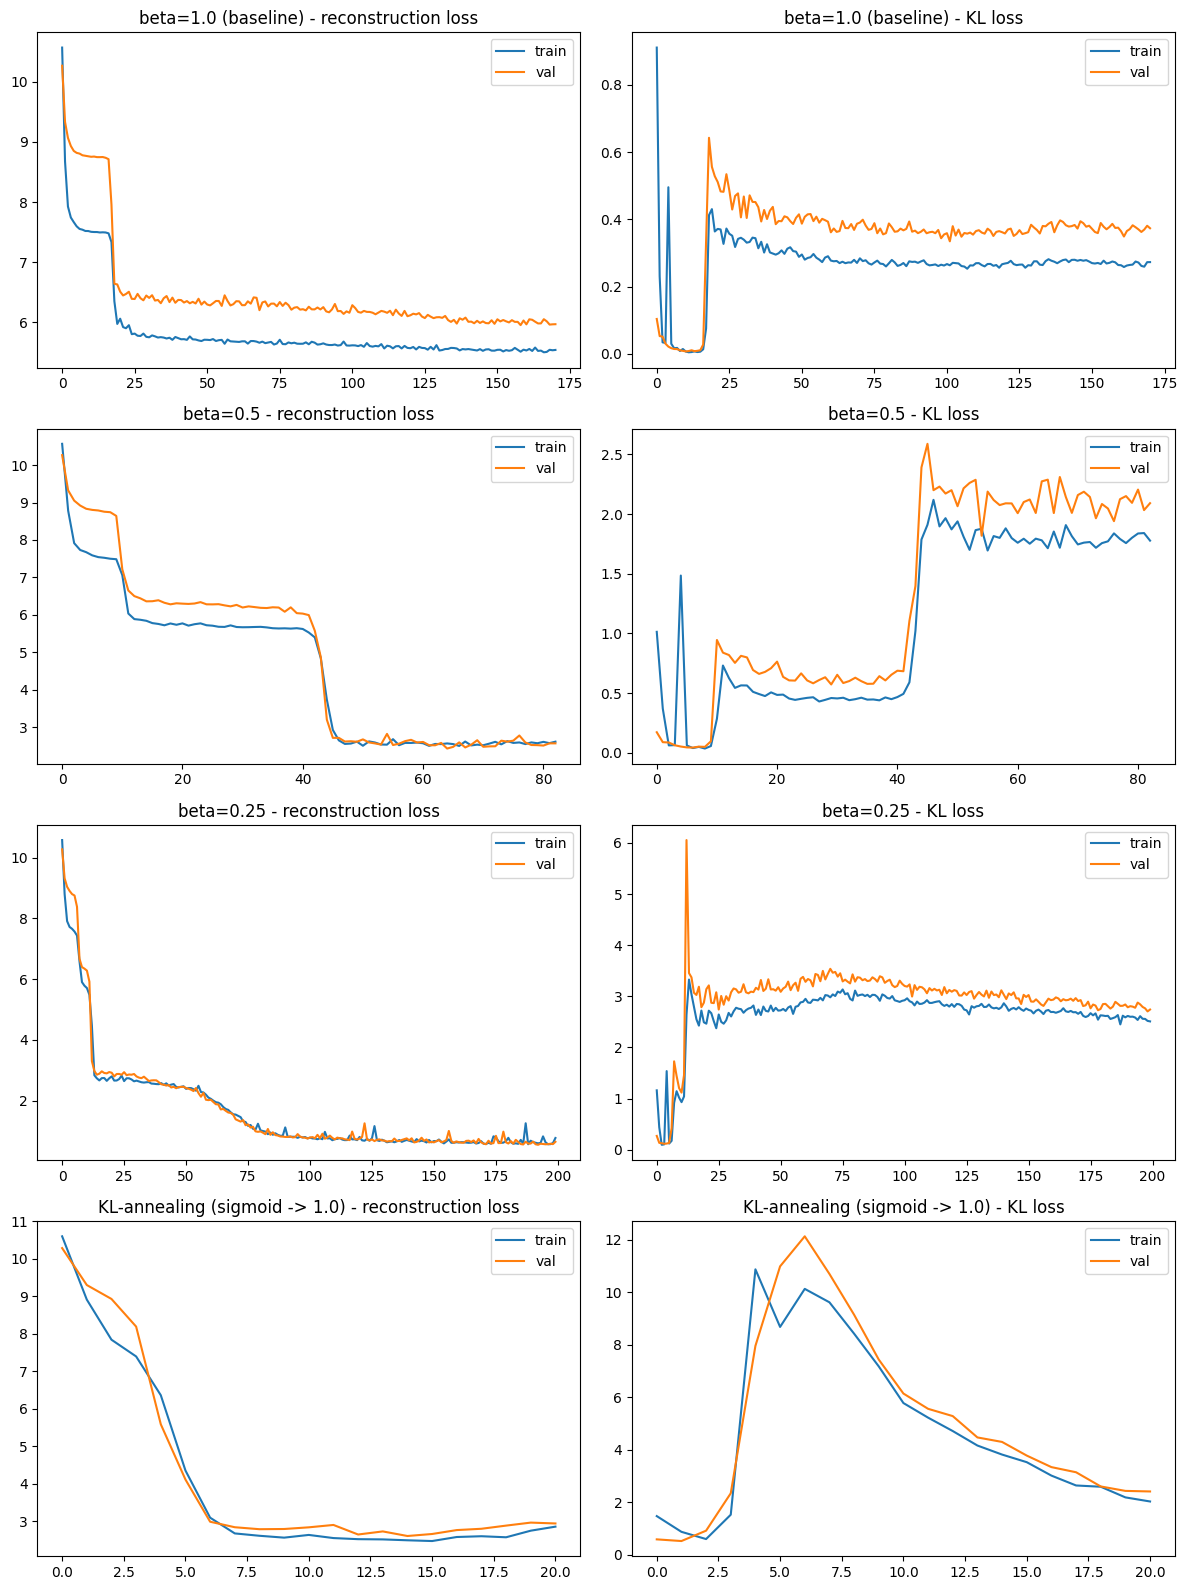

In [13]:
fig, axes = plt.subplots(len(VARIANTS), 2, figsize=(12, 4 * len(VARIANTS)))
for row, (name, _, _) in enumerate(VARIANTS):
    _, history, _ = variant_models[name]
    axes[row, 0].plot(history.history["recon_loss"], label="train")
    axes[row, 0].plot(history.history["val_recon_loss"], label="val")
    axes[row, 0].set_title(f"{name} - reconstruction loss")
    axes[row, 0].legend()
    axes[row, 1].plot(history.history["kl_loss"], label="train")
    axes[row, 1].plot(history.history["val_kl_loss"], label="val")
    axes[row, 1].set_title(f"{name} - KL loss")
    axes[row, 1].legend()
plt.tight_layout()
plt.show()


### 9.3 Selection — reasoned, not blind argmax on AUC

Rule: take the beta=1.0 baseline's test AUC as the reference. A variant is only
preferred over the baseline if it gets **more active dims** while its test AUC drop
stays within `ACTIVE_DIM_AUC_TOLERANCE` (0.03) of the baseline - a small AUC cost is
an acceptable trade for meaningfully using more of the latent space (the whole point
of this fix); a variant that loses more AUC than that isn't worth it even if it
activates every dimension. Among qualifying variants, the one with the most active
dims wins; ties broken by higher test AUC.

In [14]:
ACTIVE_DIM_AUC_TOLERANCE = 0.03
baseline_name = "beta=1.0 (baseline)"
baseline_auc = variant_df.loc[baseline_name, "test_auc"]
baseline_active = variant_df.loc[baseline_name, "n_active_dims_train"]

reasoning2 = [f"baseline ({baseline_name}): test_AUC={baseline_auc:.4f}, active_dims={baseline_active}/{chosen_latent}"]
qualifying = [(baseline_name, baseline_active, baseline_auc)]
for name, _, _ in VARIANTS:
    if name == baseline_name:
        continue
    auc = variant_df.loc[name, "test_auc"]
    active = variant_df.loc[name, "n_active_dims_train"]
    drop = baseline_auc - auc
    if drop <= ACTIVE_DIM_AUC_TOLERANCE and active > baseline_active:
        reasoning2.append(f"{name}: test_AUC={auc:.4f} (drop={drop:.4f} <= tolerance {ACTIVE_DIM_AUC_TOLERANCE}), "
                           f"active_dims={active}/{chosen_latent} > baseline's {baseline_active} -> QUALIFIES")
        qualifying.append((name, active, auc))
    elif active > baseline_active:
        reasoning2.append(f"{name}: test_AUC={auc:.4f} (drop={drop:.4f} > tolerance {ACTIVE_DIM_AUC_TOLERANCE} despite "
                           f"active_dims={active}/{chosen_latent} > baseline) -> REJECTED, AUC cost too high")
    else:
        reasoning2.append(f"{name}: test_AUC={auc:.4f}, active_dims={active}/{chosen_latent} <= baseline's "
                           f"{baseline_active} -> no improvement on the metric that matters here, REJECTED")

qualifying.sort(key=lambda t: (t[1], t[2]), reverse=True)
selected_variant = qualifying[0][0]
reasoning2.append(f"\n=> SELECTED variant: '{selected_variant}' "
                   f"(active_dims={qualifying[0][1]}/{chosen_latent}, test_AUC={qualifying[0][2]:.4f})")
print("\n".join(reasoning2))

final_model, final_history, final_stds = variant_models[selected_variant]


baseline (beta=1.0 (baseline)): test_AUC=0.9244, active_dims=1/10
beta=0.5: test_AUC=0.8880 (drop=0.0365 > tolerance 0.03 despite active_dims=6/10 > baseline) -> REJECTED, AUC cost too high
beta=0.25: test_AUC=0.9372 (drop=-0.0128 <= tolerance 0.03), active_dims=3/10 > baseline's 1 -> QUALIFIES
KL-annealing (sigmoid -> 1.0): test_AUC=0.8929 (drop=0.0315 > tolerance 0.03 despite active_dims=10/10 > baseline) -> REJECTED, AUC cost too high

=> SELECTED variant: 'beta=0.25' (active_dims=3/10, test_AUC=0.9372)


### 9.4 Save selected variant as the final Phase 3 VAE architecture

In [15]:
final_model.encoder.save(MODEL_DIR / f"vae_encoder_final.keras")
final_model.decoder.save(MODEL_DIR / f"vae_decoder_final.keras")

collapse_fix_result = {
    "active_dim_threshold": ACTIVE_STD_THRESHOLD,
    "anneal_epochs": ANNEAL_EPOCHS,
    "variant_comparison": variant_df.reset_index().to_dict(orient="records"),
    "selection_reasoning": reasoning2,
    "selected_variant": selected_variant,
    "selected_variant_active_dims_train": int(variant_df.loc[selected_variant, "n_active_dims_train"]),
    "selected_variant_per_dim_std_train": final_stds.tolist(),
}
existing = json.loads((RESULTS_DIR / "healthcheck_summary.json").read_text())
existing["collapse_fix"] = collapse_fix_result
(RESULTS_DIR / "healthcheck_summary.json").write_text(json.dumps(existing, indent=2))
print(f"Saved final architecture: {MODEL_DIR / 'vae_encoder_final.keras'}, vae_decoder_final.keras")
print(f"Updated: {RESULTS_DIR / 'healthcheck_summary.json'} (added 'collapse_fix' section)")


Saved final architecture: /Users/mustafa/Desktop/NIDS/IDS-Project/phase3_vae/04_phase3_models/vae_encoder_final.keras, vae_decoder_final.keras
Updated: /Users/mustafa/Desktop/NIDS/IDS-Project/phase3_vae/05_phase3_results/healthcheck_summary.json (added 'collapse_fix' section)


## 10. Export human-readable model files (final VAE encoder/decoder)

Same conversion Dense applies to its `.keras` files (`phase3_dense`, section 10):
next to each `.keras` file, write a JSON architecture dump (`*.json`, from
`model.get_config()`) and a plain-text layer summary (`*_readable.txt`), so the model
can be inspected without loading it in Python. Runs on the saved
`vae_encoder_final.keras` / `vae_decoder_final.keras` (loaded fresh from disk, not the
in-memory `final_model` object) so it stays correct even if this notebook is re-run
from a checkpoint or the models are regenerated independently.

VAE-specific addition (Dense's plain autoencoder doesn't need this): a short block
noting `latent_dim`, `beta`, which layers are `z_mean`/`z_log_var`, and how the
reparameterization trick combines them - since that logic lives in the `VAE2.call()`
Python code, not in either saved Keras model's own config.

In [16]:
import io

VAE_LATENT_DIM = final_model.latent_dim
VAE_BETA = 0.25  # selected variant from section 9.3

for keras_path in sorted(MODEL_DIR.glob("vae_*_final.keras")):
    m = tf.keras.models.load_model(keras_path)  # ClipLogVar is a registered Layer - default safe_mode=True works
    role = "encoder" if "encoder" in keras_path.stem else "decoder"

    json_path = keras_path.with_suffix(".json")
    json_path.write_text(json.dumps(m.get_config(), indent=2, default=str))

    buf = io.StringIO()
    m.summary(print_fn=lambda line: buf.write(line + "\n"))

    if isinstance(m.output_shape, list):
        input_size = m.input_shape[-1]
        output_desc = ", ".join(f"{name}: {shape}" for name, shape in zip(["z_mean", "z_log_var"], m.output_shape))
    else:
        input_size = m.input_shape[-1]
        output_desc = str(m.output_shape)

    txt_lines = [
        f"Model file: {keras_path.name}",
        f"Role: VAE {role} (Phase 3 VAE, final architecture - latent_dim={VAE_LATENT_DIM}, beta={VAE_BETA})",
        f"Input size: {input_size}",
        f"Output shape(s): {output_desc}",
        "(Full parameter/layer breakdown below - 'Trainable params' are the"
        " model's own weights, 'Optimizer params' is Adam's extra training-time"
        " state, not part of the architecture.)",
        "",
        "--- Layer-by-layer architecture ---",
        buf.getvalue(),
        "--- Layer details (activation, output shape, param count) ---",
    ]
    for layer in m.layers:
        cfg = layer.get_config()
        txt_lines.append(
            f"  {layer.name:20s} | type={layer.__class__.__name__:12s} | "
            f"units={cfg.get('units', '-')} | activation={cfg.get('activation', '-')} | "
            f"output_shape={layer.output.shape if hasattr(layer, 'output') else '-'} | "
            f"params={layer.count_params()}"
        )

    if role == "encoder":
        txt_lines += [
            "",
            "--- VAE-specific notes (not captured in this model's own Keras config) ---",
            f"latent_dim = {VAE_LATENT_DIM}",
            f"beta (KL weight, selected variant from section 9.3) = {VAE_BETA}",
            "z_mean layer name: 'z_mean' (Dense, linear activation, no clipping)",
            "z_log_var layer name: 'z_log_var' -> clipped to [-10, 10] via a registered "
            "ClipLogVar layer (numerical stability - see section 2, prevents exp() overflow) "
            "before being used downstream.",
            "Reparameterization trick (applied in VAE2.call(), NOT part of this saved "
            "encoder model - the encoder only outputs z_mean/z_log_var):",
            "  eps = tf.random.normal(shape=tf.shape(z_mean))",
            "  z   = z_mean + tf.exp(0.5 * z_log_var) * eps",
            "z is then fed into the decoder (this repo's vae_decoder_final.keras) to produce the reconstruction.",
        ]
    else:
        txt_lines += [
            "",
            "--- VAE-specific notes ---",
            f"Takes a sampled latent vector z (shape=({VAE_LATENT_DIM},), produced by the "
            "encoder + reparameterization trick, NOT z_mean/z_log_var directly) and reconstructs "
            "the 18-dim input feature vector (linear output activation - these are scaled/encoded "
            "features, not bounded/probabilistic outputs).",
        ]

    keras_path.with_name(keras_path.stem + "_readable.txt").write_text("\n".join(txt_lines))
    print(f"OK  {keras_path.name} -> {json_path.name} + {keras_path.stem}_readable.txt")


OK  vae_decoder_final.keras -> vae_decoder_final.json + vae_decoder_final_readable.txt


OK  vae_encoder_final.keras -> vae_encoder_final.json + vae_encoder_final_readable.txt
